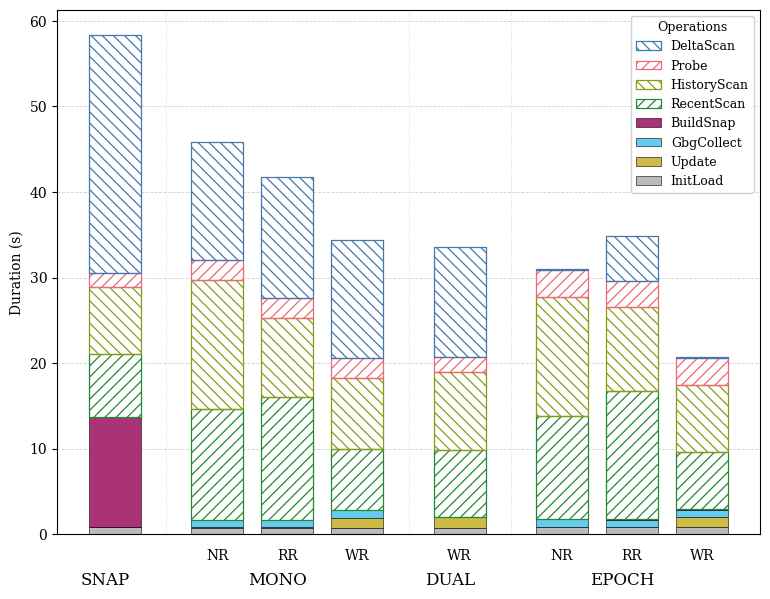

In [24]:
# Self-contained: paste into a cell and run.
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import pandas as pd

TX_MAP = {
    "MarkTs": "BuildSnap",
    "DelSc": "DeltaScan",
}

# Load CSV into a DataFrame
df = pd.read_csv("output/(UNIFORM-ANALYTICAL) Analytical Heavy_result.csv")
df["tx_type"] = df["tx_type"].replace(TX_MAP)
df.loc[df["table_type"] == "naive", "repair_type"] = ""

def draw_grouped_stacked_bar(df, title="R-heavy", subtitle="All Types"):
    # ORDER & DISPLAY NAMES
    table_order   = ["naive", "heap", "chain", "par"]  # data keys
    table_display = {"naive":"SNAP", "heap":"MONO", "chain":"DUAL", "par":"EPOCH"}

    repair_order = {
        "naive": [""],
        "heap":  ["No Repair", "Read Repair", "Write Repair"],
        "chain": ["Write Repair"],
        "par":   ["No Repair", "Read Repair", "Write Repair"],
    }
    repair_display = {"No Repair":"NR", "Read Repair":"RR", "Write Repair":"WR", "": ""}

    # STACK ORDER (bottom -> top)
    tx_order   = ["InitLoad", "Update", "GbgCollect", "BuildSnap", "RecentScan", "HistoryScan", "Probe", "DeltaScan"]
    # MarkTs = WRITE (solid)
    write_like = {"InitLoad", "Update", "GbgCollect", "BuildSnap"}
    read_like  = {"Probe", "RecentScan", "HistoryScan", "DeltaScan"}

    # Paul Tol "Bright" palette
    tol = {
        "blue":   "#4477AA",
        "cyan":   "#66CCEE",
        "green":  "#228833",
        "yellow": "#CCBB44",
        "red":    "#EE6677",
        "purple": "#AA3377",
        "grey":   "#BBBBBB",
        "darkgreen": "#8C9916",
    }
    # color_map = {
    #     "InitLoad":  tol["blue"],
    #     "Update":    tol["green"],
    #     "GbgCollect":tol["red"],
    #     "BuildSnap":    tol["purple"],
    #     "Probe":     tol["cyan"],
    #     "Scan":      tol["yellow"],
    #     "DeltaScan":     tol["grey"],
    # }
    color_map = {
        "InitLoad":  tol["grey"],
        "Update":    tol["yellow"],
        "GbgCollect":tol["cyan"],
        "BuildSnap":    tol["purple"],
        "Probe":     tol["red"],
        "RecentScan":      tol["green"],
        "HistoryScan":      tol["darkgreen"],
        "DeltaScan":     tol["blue"],
    }

    # READ hatch orientations (alternate): 
    # DelSc: backslash ( \ ), Scan: slash ( / ), Probe: backslash ( \ )
    hatch_read_map = {
        "DeltaScan": "\\\\\\",
        "Probe":  "///",
        "HistoryScan": "\\\\\\",
        "RecentScan": "///",
    }

    # Times New Roman
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"]  = ["Times New Roman", "Times", "Nimbus Roman No9 L", "DejaVu Serif"]
    plt.rcParams["hatch.linewidth"] = 0.9

    # pivot (ms) -> seconds
    pvt = (
        df.pivot_table(index=["table_type","repair_type"],
                       columns="tx_type", values="duration_ms",
                       aggfunc="sum", fill_value=0.0)
        .reindex(columns=tx_order, fill_value=0.0)
    ) / 1000.0


    # x positions (two-tier labels)
    bar_w = 0.58
    gap   = 0.36
    bar_x, minor_labels, major_centers, major_labels, combos = [], [], [], [], []
    x = 0.0
    for t in table_order:
        subs = repair_order[t]
        start = x
        for r in subs:
            bar_x.append(x)
            minor_labels.append(repair_display[r])  # NR/RR/WR
            combos.append((t, r))
            x += 0.78
        end = x - 1.0
        major_centers.append((start + end) / 2.0)
        major_labels.append(table_display[t])
        x += gap

    # slightly taller aspect ratio
    fig, ax = plt.subplots(figsize=(7.8, 6.0))
    fig.subplots_adjust(bottom=0.22)

    # stacked bars
    for i, (t, r) in enumerate(combos):
        row = pvt.loc[(t, r)] if (t, r) in pvt.index else pd.Series(0.0, index=tx_order)
        bottom = 0.0
        for tx in tx_order:
            v = float(row.get(tx, 0.0))
            if v <= 0:
                continue
            if tx in write_like:
                # WRITE: solid
                ax.bar(
                    bar_x[i], v, bottom=bottom, width=bar_w,
                    color=color_map[tx], edgecolor="black", linewidth=0.4, zorder=2
                )
            else:
                # READ: white base + colored hatch overlay (orientation per tx)
                ax.bar(
                    bar_x[i], v, bottom=bottom, width=bar_w,
                    color="white", edgecolor="black", linewidth=0.4, zorder=2
                )
                ax.bar(
                    bar_x[i], v, bottom=bottom, width=bar_w,
                    color="none", edgecolor=color_map[tx], linewidth=0.9,
                    hatch=hatch_read_map.get(tx, "///"), zorder=3
                )
            bottom += v

    # custom x labels (two lines, close to axis)
    ax.set_xticks([])
    for xi, lab in zip(bar_x, minor_labels):
        ax.text(xi, -0.028, lab, ha="center", va="top",
                transform=ax.get_xaxis_transform(), fontsize=10, clip_on=False)
    for xc, lab in zip(major_centers, major_labels):
        ax.text(xc, -0.072, lab, ha="center", va="top",
                transform=ax.get_xaxis_transform(), fontsize=12, clip_on=False)

    # separators between major groups
    for k in range(1, len(major_centers)):
        prev_end   = max([xx for xx,(tt,_) in zip(bar_x, combos) if tt == table_order[k-1]])
        next_start = min([xx for xx,(tt,_) in zip(bar_x, combos) if tt == table_order[k]])
        ax.axvline((prev_end + next_start)/2, linestyle=":", linewidth=0.6, alpha=0.3)

    # y-axis
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
    ax.set_ylabel("Duration (s)")

    # Title (exactly as provided)
    ax.set_title(title)

    # Legend (manual so READ shows hatch per-op, WRITE are solid), reversed order
    handles, labels = [], []
    for tx in tx_order[::-1]:
        if tx in write_like:
            patch = Patch(facecolor=color_map[tx], edgecolor="black", linewidth=0.4)
        else:
            patch = Patch(facecolor="white", edgecolor=color_map[tx],
                          hatch=hatch_read_map.get(tx, "///"), linewidth=0.9)
        handles.append(patch)
        labels.append(tx)

    ax.legend(handles, labels, title="Operations",
              loc="upper right", framealpha=0.9, fontsize=9, title_fontsize=9)

    plt.tight_layout()
    plt.show()

draw_grouped_stacked_bar(df, title="", subtitle="All Types")